In [1]:
import sys
import numpy as np
import anndata as ad
import polars as pl
import src as scit

/home/aleksander-work/Skrivbord/pyproject/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
mt = ad.read_h5ad('private/data/clean_method/mutant_inferred.h5ad')

In [3]:
cttag = ad.read_h5ad('private/data/clean_method/cttag_wt_inferred.h5ad')
cttag = cttag[cttag.obs['timep']=='14_16h'].copy()

In [2]:
rna_change = pl.read_csv('private/data/wt_mt_rna_change.csv')
rna_change

pval,score,name,base_mean,group
f64,f64,str,f64,str
1.0,-0.055835,"""l(2)gl""",0.244264,"""Muscle somatic"""
1.0,0.0,"""CR11023""",0.0,"""Muscle somatic"""
1.0,-0.068216,"""spen""",1.533592,"""Muscle somatic"""
0.00009,0.519544,"""kis""",0.848222,"""Muscle somatic"""
0.003386,-1.159945,"""Cda5""",0.142047,"""Muscle somatic"""
…,…,…,…,…
1.0,0.0,"""lncRNA:CR45123""",0.0,"""Neuronal 2"""
1.0,0.0,"""Vml""",0.0,"""Neuronal 2"""
1.0,0.0,"""CG14422""",0.0,"""Neuronal 2"""


In [82]:
active_meth = pl.read_csv('private/data/meth_active.csv', has_header=False)['column_1'].to_numpy()
#muscle_up = pl.read_csv('private/muscle_meth_up.txt', has_header=False).to_numpy().ravel()
#muscle_down = pl.read_csv('private/muscle_meth_down.txt', has_header=False).to_numpy().ravel()

In [100]:
lc_acet = scit.tl.make_layer_config(
    "acet",
    in_obsm=False,
    #log_transform=True,
    normalize_with_obs_counts=True,
    feature_names=cttag.uns['gene_names_acet']
)
lc_meth = scit.tl.make_layer_config(
    "meth",
    in_obsm=False,
    #log_transform=True,
    normalize_with_obs_counts=True,
    feature_names=cttag.uns['gene_names_acet']
)

In [101]:
from src.tools._layers import get_layer_feature_means
acet_means = get_layer_feature_means(cttag[cttag.obs['label'] == 'Muscle'], lc_acet)
acet_means_d = dict(zip(cttag.uns['gene_names_acet'], acet_means))
pl.DataFrame(acet_means_d).transpose(include_header=True).write_csv('private/data/acet_means_muscle.csv')
meth_means = get_layer_feature_means(cttag[cttag.obs['label'] == 'Muscle'], lc_meth)
meth_means_d = dict(zip(cttag.uns['gene_names_acet'], meth_means))
pl.DataFrame(meth_means_d).transpose(include_header=True).write_csv('private/data/meth_means_muscle.csv')

rna_change_muscle = rna_change.filter(pl.col('group').is_in(['Muscle somatic', 'Muscle visceral']))#, 'Fat Body']))

In [102]:
rna_change_muscle = rna_change_muscle.with_columns(
    pl.col('name').replace_strict(meth_means_d, default=np.nan).alias('meth_mean'),
    pl.col('pval').map_elements(lambda x: -np.log10(x)).alias('ppval')
)
muscle_up = rna_change_muscle.filter(pl.col('score')>0.25).filter(pl.col('pval')<0.0001)['name'].to_numpy()
muscle_down = rna_change_muscle.filter(pl.col('score')<-0.25).filter(pl.col('pval')<0.0001)['name'].to_numpy()
print(len(muscle_up))
print(len(muscle_down))
rna_change_muscle

373
115


/tmp/nix-shell-19018-0/ipykernel_19074/2240796458.py:3: PolarsInefficientMapWarning: 
Expr.map_elements is significantly slower than the native expressions API.
Only use if you absolutely CANNOT implement your logic otherwise.
Replace this expression...
  - pl.col("pval").map_elements(lambda x: ...)
with this one instead:
  + -pl.col("pval").log10()

  pl.col('pval').map_elements(lambda x: -np.log10(x)).alias('ppval')
/tmp/nix-shell-19018-0/ipykernel_19074/2240796458.py:3: RuntimeWarning: divide by zero encountered in log10
  pl.col('pval').map_elements(lambda x: -np.log10(x)).alias('ppval')
/tmp/nix-shell-19018-0/ipykernel_19074/2240796458.py:3: RuntimeWarning: divide by zero encountered in log10
  pl.col('pval').map_elements(lambda x: -np.log10(x)).alias('ppval')
/tmp/nix-shell-19018-0/ipykernel_19074/2240796458.py:3: RuntimeWarning: divide by zero encountered in log10
  pl.col('pval').map_elements(lambda x: -np.log10(x)).alias('ppval')
/tmp/nix-shell-19018-0/ipykernel_19074/22407964

pval,score,name,base_mean,group,meth_mean,ppval
f64,f64,str,f64,str,f64,f64
1.0,-0.055835,"""l(2)gl""",0.244264,"""Muscle somatic""",0.117407,-0.0
1.0,0.0,"""CR11023""",0.0,"""Muscle somatic""",0.649354,-0.0
1.0,-0.068216,"""spen""",1.533592,"""Muscle somatic""",0.040981,-0.0
0.00009,0.519544,"""kis""",0.848222,"""Muscle somatic""",0.040445,4.047532
0.003386,-1.159945,"""Cda5""",0.142047,"""Muscle somatic""",0.21831,2.47028
…,…,…,…,…,…,…
1.0,0.0,"""lncRNA:CR45123""",0.0,"""Muscle visceral""",NaN,-0.0
1.0,0.0,"""Vml""",0.0,"""Muscle visceral""",NaN,-0.0
1.0,0.0,"""CG14422""",0.0,"""Muscle visceral""",0.216141,-0.0


In [103]:
# df = rna_change_muscle.filter(pl.col('meth_mean').is_not_nan()).filter(pl.col('ppval') != 0)
# scit.pl.int.scatter(
#     [
#         np.c_[df['score'].to_numpy(), df['meth_mean'].to_numpy()],
#         #np.c_[df.filter(pl.col('score')<0)['ppval'].to_numpy(), df.filter(pl.col('score')<0)['meth_mean'].to_numpy()],
#     ],
#     yminmax=(-0.1,5), alpha=0.4
# 
# )


In [104]:
import polars as pl
mt_muscle_meth = pl.read_csv('private/data/wt_mt_meth_change.csv').filter((pl.col('base_mean') > 0.5) & (pl.col('group') == 'Muscle'))
mt_muscle_acet = pl.read_csv('private/data/wt_mt_acet_change.csv').filter((pl.col('base_mean') > 0.5) & (pl.col('group') == 'Muscle'))

In [105]:
mt_muscle_meth = mt_muscle_meth.filter(pl.col('base_mean') > 0.2)#.filter(pl.col('pval')<0.1)
mt_muscle_meth = mt_muscle_meth.with_columns(
    np.log10(pl.col('pval')).neg().alias('ppval')
).with_columns(
    #(pl.col('ppval') * pl.col('score').sign()).alias('adj_score')
    (pl.col('ppval') * pl.col('score')).alias('adj_score')
).sort('adj_score')
mt_muscle_meth

pval,score,name,base_mean,group,ppval,adj_score
f64,f64,str,f64,str,f64,f64
0.000005,-1.501535,"""RecQ5""",3.6155922,"""Muscle""",5.291242,-7.944984
9.6701e-7,-0.943194,"""mirr""",16.954054,"""Muscle""",6.01457,-5.672907
0.00001,-1.113462,"""Npc2h""",5.8908215,"""Muscle""",5.004793,-5.572645
0.000106,-1.345553,"""CG14488""",2.4963493,"""Muscle""",3.973007,-5.345891
0.00091,-1.577227,"""stumps""",1.7489872,"""Muscle""",3.04073,-4.795923
…,…,…,…,…,…,…
0.000683,1.2459685,"""CG13921""",0.5397718,"""Muscle""",3.165385,3.943971
0.011441,2.1520226,"""asRNA:CR46071""",0.5641213,"""Muscle""",1.941537,4.178232
0.002321,1.704604,"""lncRNA:CR44955""",0.5114186,"""Muscle""",2.63437,4.490557


In [111]:
mt_muscle_meth[['name']].write_csv('/tmp/muscle_list.csv')

In [108]:
mp = muscle_up
#mp = list(mt_muscle_meth.filter(pl.col('adj_score')<-0.5)['name'])
for m in mp:
    print(m)

kis
Gs1
ND-15
CG3436
lwr
RFeSP
Eno
Npc2a
GlyP
CG10874
Axud1
Elba2
HINT1
ND-PDSW
ND-B14.5B
Rtnl1
eIF3i
ND-13A
cype
CR14033
Lam
Hel25E
Sec61alpha
chic
Kdm5
Pfdn1
Kr-h2
Cpr
Arpc4
COX5B
Hrb27C
Phf5a
CG34310
nrv2
Sumo
CG5177
mEFG1
Rack1
r2d2
SmE
CG13096
poe
Sirup
Akap200
emb
Su(var)205
MED20
CG7840
Acbp1
PrBP
Trp1
eEF1delta
me31B
Mdh1
Cdk1
SmB
porin
ATPsynG
EMC3
cana
bru1
Nnp-1
vig
CG31775
CG42586
cni
CG5861
Cyt-c-p
Prosbeta4
BicD
CG10413
EMC5
Faf2
COX4
pths
CG9336
eEF2
Lamp1
Df31
RNASEK
CG30159
Glo1
wech
CG12107
CG14764
Ggamma1
VhaAC45
Tom7
tsu
CG12129
14-3-3zeta
COX7C
Vamp7
CG12909
ND-B14
CG7637
Prosbeta5
Tapdelta
CG13220
TpnC47D
eEF1alpha1
ERp60
CCT5
bic
Nacalpha
ND-MWFE
Echs1
drk
ReepB
SmydA-1
Hsc70-5
Su(var)2-HP2
ND-B15
Cyp6a8
aPKC
CG30080
CG44243
Prosbeta1
eEF1beta
Prosalpha5
UQCR-6.4
Smurf
EMRE
Fkbp12
Phb2
betaTub56D
EloC
CG11007
CG13868
CG13427
Act57B
Fkbp14
Prosalpha3
mago
ND-B12
eIF3k
Snp
CG2852
blw
CycB
CNBP
l(2)k09913
roh
levy
l(2)efl
Eglp4
tsr
CG5554
CG5532
Mlp60A
eEF5
betaTub6

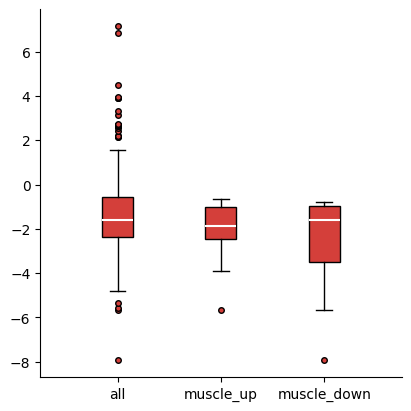

(None,)

In [69]:
scit.set_defaults(figsize=(4,4))
scit.pl.int.boxplot(
    [mt_muscle_meth['adj_score'].to_numpy(), mt_muscle_meth.filter(pl.col('name').is_in(muscle_up))['adj_score'].to_numpy(), mt_muscle_meth.filter(pl.col('name').is_in(muscle_down))['adj_score'].to_numpy()],
    ['all', 'muscle_up', 'muscle_down']
),